# Orographic Analysis - Hillerød Golf Course

This notebook performs a comprehensive terrain analysis to understand:
- **Elevation patterns** - height variations across the landscape
- **Flow characteristics** - how water moves across the terrain  
- **Roughness metrics** - terrain complexity and ruggedness

## Analysis includes:
1. 📥 Downloading high-resolution elevation data (SRTM)
2. 🗻 Hillshade and 3D terrain visualization
3. 📐 Slope and aspect calculations
4. 🪨 Terrain Ruggedness Index (TRI)
5. 💧 Flow direction and accumulation analysis
6. 🌊 Stream network identification

## Instructions:
1. First, install required packages by uncommenting and running the installation cell
2. Run cells sequentially from top to bottom
3. Adjust the location coordinates if you want to analyze a different area

---

In [5]:
import numpy as np
import rasterio
from rasterio.plot import show
import matplotlib.pyplot as plt
from matplotlib.colors import LightSource
from shapely import bounds
import subprocess
import os

In [13]:
# Download elevation data using the 'elevation' package
# This downloads SRTM data (Shuttle Radar Topography Mission)


output_file = 'hillerod_dem.tif'

# Build the command
# Ensure required coordinates/buffer exist (works even if cell 11 has not been run yet)
if 'latitude' not in globals():
    latitude = 55.93
if 'longitude' not in globals():
    longitude = 12.30
if 'buffer_deg' not in globals():
    buffer_deg = (buffer_km / 111) if 'buffer_km' in globals() else (1.5 / 111)

cmd = (
    f"eio clip -o {output_file} --bounds "
    f"{longitude - buffer_deg} {latitude - buffer_deg} "
    f"{longitude + buffer_deg} {latitude + buffer_deg}"
)

print(f"Downloading elevation data...")
print(f"Command: {cmd}")

try:
    result = subprocess.run(cmd, shell=True, capture_output=True, text=True)
    if result.returncode == 0:
        print("✓ Download complete!")
    else:
        print(f"Error: {result.stderr}")
except Exception as e:
    print(f"Error downloading data: {e}")
    print("You may need to install the elevation package: pip install elevation")

Command: eio clip -o hillerod_dem.tif --bounds 12.286486486486487 55.916486486486484 12.313513513513515 55.943513513513516
Error: 'eio' is not recognized as an internal or external command,
operable program or batch file.



In [11]:
# Calculate slope (gradient) in degrees
def calculate_slope(dem, cell_size):
    """Calculate slope from DEM in degrees"""
    dy, dx = np.gradient(dem, cell_size)
    slope = np.arctan(np.sqrt(dx**2 + dy**2))
    slope_deg = np.degrees(slope)
    return slope_deg

# Calculate aspect (direction of slope)
def calculate_aspect(dem, cell_size):
    """Calculate aspect from DEM in degrees (0-360, clockwise from North)"""
    dy, dx = np.gradient(dem, cell_size)
    aspect = np.arctan2(-dx, dy)
    aspect_deg = np.degrees(aspect)
    aspect_deg = (90 - aspect_deg) % 360
    return aspect_deg

# Calculate Terrain Ruggedness Index (TRI)
def calculate_tri(dem):
    """Calculate Terrain Ruggedness Index - measure of local elevation variation"""
    tri = np.zeros_like(dem)
    for i in range(-1, 2):
        for j in range(-1, 2):
            if i == 0 and j == 0:
                continue
            shifted = np.roll(np.roll(dem, i, axis=0), j, axis=1)
            tri += np.abs(dem - shifted)
    return tri / 8

# Estimate cell size from transform
cell_size = abs(transform[0])  # pixel width in degrees
cell_size_m = cell_size * 111000  # convert to meters (approximate)

print(f"Cell size: ~{cell_size_m:.1f} meters")

NameError: name 'transform' is not defined

NameError: name 'elevation_data' is not defined

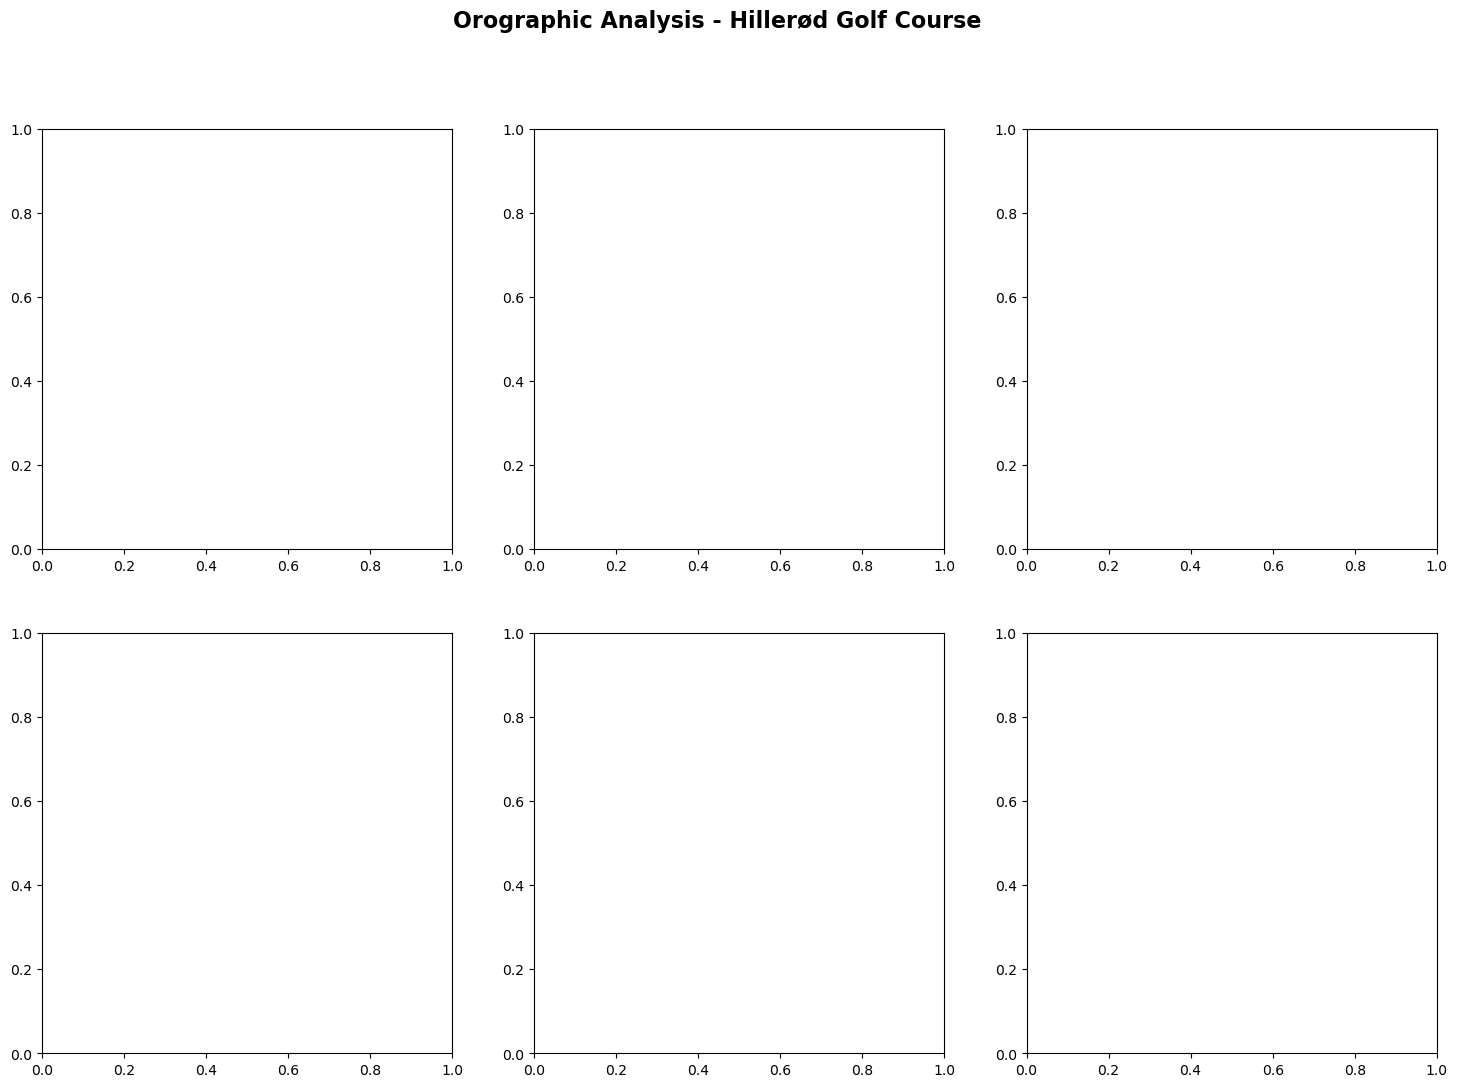

In [8]:
# Create a comprehensive orographic visualization
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.suptitle('Orographic Analysis - Hillerød Golf Course', fontsize=16, fontweight='bold')

# 1. Hillshade visualization
ls = LightSource(azdeg=315, altdeg=45)
hillshade = ls.hillshade(elevation_data, vert_exag=2)
ax1 = axes[0, 0]
im1 = ax1.imshow(hillshade, cmap='gray')
ax1.set_title('Hillshade (relief)', fontweight='bold')
ax1.axis('off')

# 2. Elevation with contours
ax2 = axes[0, 1]
im2 = ax2.imshow(elevation_data, cmap='terrain')
contours = ax2.contour(elevation_data, levels=10, colors='black', alpha=0.3, linewidths=0.5)
ax2.clabel(contours, inline=True, fontsize=8, fmt='%1.0f m')
ax2.set_title('Elevation (meters)', fontweight='bold')
ax2.axis('off')
plt.colorbar(im2, ax=ax2, fraction=0.046, pad=0.04)

# 3. Slope
ax3 = axes[0, 2]
im3 = ax3.imshow(slope, cmap='YlOrRd')
ax3.set_title('Slope (degrees)', fontweight='bold')
ax3.axis('off')
plt.colorbar(im3, ax=ax3, fraction=0.046, pad=0.04)

# 4. Aspect
ax4 = axes[1, 0]
im4 = ax4.imshow(aspect, cmap='hsv', vmin=0, vmax=360)
ax4.set_title('Aspect (flow direction)', fontweight='bold')
ax4.axis('off')
cbar4 = plt.colorbar(im4, ax=ax4, fraction=0.046, pad=0.04)
cbar4.set_label('Degrees from North')

# 5. Terrain Ruggedness Index
ax5 = axes[1, 1]
im5 = ax5.imshow(tri, cmap='plasma')
ax5.set_title('Terrain Ruggedness Index (TRI)', fontweight='bold')
ax5.axis('off')
plt.colorbar(im5, ax=ax5, fraction=0.046, pad=0.04)

# 6. Combined: Hillshade with elevation overlay
ax6 = axes[1, 2]
ax6.imshow(hillshade, cmap='gray')
im6 = ax6.imshow(elevation_data, cmap='terrain', alpha=0.5)
ax6.set_title('Combined: Relief + Elevation', fontweight='bold')
ax6.axis('off')
plt.colorbar(im6, ax=ax6, fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()

In [ ]:
# Visualize flow analysis
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Flow Analysis - Hillerød Golf Course', fontsize=16, fontweight='bold')

# 1. Flow direction overlay on hillshade
ax1 = axes[0]
ax1.imshow(hillshade, cmap='gray')
# Create arrow visualization for flow direction (sample every N pixels for clarity)
step = max(1, max(elevation_data.shape) // 40)
y, x = np.mgrid[0:elevation_data.shape[0]:step, 0:elevation_data.shape[1]:step]

# Direction mapping for arrows
dir_vectors = {
    1: (0, 1), 2: (1, 1), 4: (1, 0), 8: (1, -1),
    16: (0, -1), 32: (-1, -1), 64: (-1, 0), 128: (-1, 1), 0: (0, 0)
}

u = np.zeros_like(x, dtype=float)
v = np.zeros_like(y, dtype=float)

for i, yi in enumerate(range(0, elevation_data.shape[0], step)):
    for j, xi in enumerate(range(0, elevation_data.shape[1], step)):
        if yi < elevation_data.shape[0] and xi < elevation_data.shape[1]:
            fd = flow_direction[yi, xi]
            if fd in dir_vectors:
                dy, dx = dir_vectors[fd]
                u[i, j] = dx
                v[i, j] = dy

ax1.quiver(x, y, u, v, color='blue', alpha=0.6, scale=30, width=0.003)
ax1.set_title('Flow Direction Vectors', fontweight='bold')
ax1.axis('off')

# 2. Flow accumulation (log scale for better visualization)
ax2 = axes[1]
flow_acc_log = np.log10(flow_accumulation + 1)  # +1 to avoid log(0)
im2 = ax2.imshow(flow_acc_log, cmap='Blues')
ax2.set_title('Flow Accumulation (log scale)', fontweight='bold')
ax2.axis('off')
cbar2 = plt.colorbar(im2, ax=ax2, fraction=0.046, pad=0.04)
cbar2.set_label('log10(accumulated cells)')

# 3. Stream network (high flow accumulation)
ax3 = axes[2]
ax3.imshow(hillshade, cmap='gray')
threshold = np.percentile(flow_accumulation[~np.isnan(flow_accumulation)], 95)
streams = np.where(flow_accumulation > threshold, 1, np.nan)
im3 = ax3.imshow(streams, cmap='Blues', alpha=0.8)
ax3.set_title(f'Potential Stream Network\n(top 5% flow accumulation)', fontweight='bold')
ax3.axis('off')

plt.tight_layout()
plt.show()

print(f"Flow accumulation range: {np.nanmin(flow_accumulation):.0f} to {np.nanmax(flow_accumulation):.0f} cells")
print(f"Stream threshold: {threshold:.0f} cells")

In [ ]:
# Summary statistics and terrain characterization
print("=" * 60)
print("OROGRAPHIC ANALYSIS SUMMARY - HILLERØD GOLF COURSE")
print("=" * 60)
print(f"\n📍 Location: Latitude {latitude}°, Longitude {longitude}°")
print(f"📐 Area analyzed: {buffer_km*2:.1f} km × {buffer_km*2:.1f} km")
print(f"🔍 Data resolution: ~{cell_size_m:.1f} meters per pixel")
print(f"📊 Grid size: {elevation_data.shape[0]} × {elevation_data.shape[1]} pixels")

print(f"\n🏔️  ELEVATION:")
print(f"   Min: {np.nanmin(elevation_data):.1f} m")
print(f"   Max: {np.nanmax(elevation_data):.1f} m")
print(f"   Mean: {np.nanmean(elevation_data):.1f} m")
print(f"   Range: {np.nanmax(elevation_data) - np.nanmin(elevation_data):.1f} m")

print(f"\n📐 SLOPE:")
print(f"   Min: {np.nanmin(slope):.2f}°")
print(f"   Max: {np.nanmax(slope):.2f}°")
print(f"   Mean: {np.nanmean(slope):.2f}°")
print(f"   Median: {np.nanmedian(slope):.2f}°")

# Classify slope
flat_percent = np.sum(slope < 2) / np.sum(~np.isnan(slope)) * 100
gentle_percent = np.sum((slope >= 2) & (slope < 5)) / np.sum(~np.isnan(slope)) * 100
moderate_percent = np.sum((slope >= 5) & (slope < 15)) / np.sum(~np.isnan(slope)) * 100
steep_percent = np.sum(slope >= 15) / np.sum(~np.isnan(slope)) * 100

print(f"\n   Terrain classification:")
print(f"   - Flat (< 2°): {flat_percent:.1f}%")
print(f"   - Gentle (2-5°): {gentle_percent:.1f}%")
print(f"   - Moderate (5-15°): {moderate_percent:.1f}%")
print(f"   - Steep (> 15°): {steep_percent:.1f}%")

print(f"\n🪨 ROUGHNESS (TRI):")
print(f"   Min: {np.nanmin(tri):.2f}")
print(f"   Max: {np.nanmax(tri):.2f}")
print(f"   Mean: {np.nanmean(tri):.2f}")
print(f"   Median: {np.nanmedian(tri):.2f}")

print(f"\n💧 FLOW CHARACTERISTICS:")
print(f"   Max flow accumulation: {np.nanmax(flow_accumulation):.0f} cells")
print(f"   Potential drainage area: ~{np.nanmax(flow_accumulation) * (cell_size_m**2) / 1e6:.3f} km²")

print("\n" + "=" * 60)
print("Analysis complete! ✓")
print("=" * 60)

In [ ]:
# 3D Surface visualization
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(14, 10))

# Create two 3D subplots
ax1 = fig.add_subplot(121, projection='3d')
ax2 = fig.add_subplot(122, projection='3d')

# Downsample for faster rendering
step = max(1, max(elevation_data.shape) // 100)
X, Y = np.meshgrid(
    np.arange(0, elevation_data.shape[1], step),
    np.arange(0, elevation_data.shape[0], step)
)
Z = elevation_data[::step, ::step]

# Plot 1: Terrain colored by elevation
surf1 = ax1.plot_surface(X, Y, Z, cmap='terrain', 
                          linewidth=0, antialiased=True, alpha=0.9)
ax1.set_title('3D Terrain - Colored by Elevation', fontweight='bold', pad=20)
ax1.set_xlabel('X (pixels)')
ax1.set_ylabel('Y (pixels)')
ax1.set_zlabel('Elevation (m)')
ax1.view_init(elev=30, azim=45)
fig.colorbar(surf1, ax=ax1, shrink=0.5, aspect=5)

# Plot 2: Terrain colored by slope
slope_sampled = slope[::step, ::step]
surf2 = ax2.plot_surface(X, Y, Z, facecolors=plt.cm.YlOrRd(slope_sampled/slope_sampled.max()),
                          linewidth=0, antialiased=True, alpha=0.9)
ax2.set_title('3D Terrain - Colored by Slope', fontweight='bold', pad=20)
ax2.set_xlabel('X (pixels)')
ax2.set_ylabel('Y (pixels)')
ax2.set_zlabel('Elevation (m)')
ax2.view_init(elev=30, azim=45)

plt.tight_layout()
plt.show()

In [ ]:
# Calculate flow direction using D8 algorithm (simplified)
def calculate_flow_direction_d8(dem):
    """
    Calculate flow direction using D8 algorithm
    Returns flow direction codes: 1=E, 2=SE, 4=S, 8=SW, 16=W, 32=NW, 64=N, 128=NE
    """
    rows, cols = dem.shape
    flow_dir = np.zeros_like(dem, dtype=np.int32)
    
    # Direction vectors (E, SE, S, SW, W, NW, N, NE)
    directions = [(0, 1), (1, 1), (1, 0), (1, -1), (0, -1), (-1, -1), (-1, 0), (-1, 1)]
    dir_codes = [1, 2, 4, 8, 16, 32, 64, 128]
    
    for i in range(1, rows-1):
        for j in range(1, cols-1):
            if np.isnan(dem[i, j]):
                continue
                
            max_slope = -np.inf
            max_dir = 0
            
            for d_idx, (di, dj) in enumerate(directions):
                ni, nj = i + di, j + dj
                if 0 <= ni < rows and 0 <= nj < cols and not np.isnan(dem[ni, nj]):
                    # Calculate slope
                    distance = cell_size_m * (1.414 if di != 0 and dj != 0 else 1)
                    slope = (dem[i, j] - dem[ni, nj]) / distance
                    
                    if slope > max_slope:
                        max_slope = slope
                        max_dir = dir_codes[d_idx]
            
            flow_dir[i, j] = max_dir
    
    return flow_dir

# Calculate flow accumulation (simplified - counts cells flowing into each cell)
def calculate_flow_accumulation(dem, flow_dir):
    """Calculate flow accumulation from flow direction"""
    rows, cols = dem.shape
    flow_acc = np.ones_like(dem, dtype=np.float32)
    
    # Create a list of cells sorted by elevation (process from high to low)
    cells = []
    for i in range(rows):
        for j in range(cols):
            if not np.isnan(dem[i, j]):
                cells.append((dem[i, j], i, j))
    
    cells.sort(reverse=True)  # Sort by elevation descending
    
    # Direction mapping
    dir_map = {
        1: (0, 1), 2: (1, 1), 4: (1, 0), 8: (1, -1),
        16: (0, -1), 32: (-1, -1), 64: (-1, 0), 128: (-1, 1)
    }
    
    # Process each cell
    for _, i, j in cells:
        if flow_dir[i, j] in dir_map:
            di, dj = dir_map[flow_dir[i, j]]
            ni, nj = i + di, j + dj
            if 0 <= ni < rows and 0 <= nj < cols:
                flow_acc[ni, nj] += flow_acc[i, j]
    
    return flow_acc

print("Calculating flow direction...")
flow_direction = calculate_flow_direction_d8(elevation_data)
print("Calculating flow accumulation...")
flow_accumulation = calculate_flow_accumulation(elevation_data, flow_direction)
print("Flow analysis complete!")

In [ ]:
# Calculate terrain metrics
slope = calculate_slope(elevation_data, cell_size_m)
aspect = calculate_aspect(elevation_data, cell_size_m)
tri = calculate_tri(elevation_data)

print("Terrain metrics calculated:")
print(f"  Slope range: {np.nanmin(slope):.2f}° to {np.nanmax(slope):.2f}°")
print(f"  Mean slope: {np.nanmean(slope):.2f}°")
print(f"  TRI range: {np.nanmin(tri):.2f} to {np.nanmax(tri):.2f}")
print(f"  Mean TRI: {np.nanmean(tri):.2f}")

In [ ]:
# Load the elevation data
with rasterio.open(output_file) as src:
    elevation_data = src.read(1)
    elevation_meta = src.meta
    transform = src.transform
    crs = src.crs
    
    # Get no data value
    nodata = src.nodata
    if nodata is not None:
        elevation_data = np.where(elevation_data == nodata, np.nan, elevation_data)

print(f"Elevation data shape: {elevation_data.shape}")
print(f"Elevation range: {np.nanmin(elevation_data):.1f} to {np.nanmax(elevation_data):.1f} meters")
print(f"CRS: {crs}")

In [ ]:
# Define the area of interest - Hillerød Golf Course
# Coordinates in decimal degrees (WGS84)
latitude = 55.93  # Hillerød golf course approximate center
longitude = 12.30
buffer_km = 1.5  # Area to download (km radius)

# Calculate bounding box
buffer_deg = buffer_km / 111  # Rough conversion: 1 degree ≈ 111 km
bounds = (
    longitude - buffer_deg,  # West
    latitude - buffer_deg,   # South
    longitude + buffer_deg,  # East
    latitude + buffer_deg    # North
)

print(f"Area of interest: {bounds}")
print(f"Center: Lat {latitude}, Lon {longitude}")

In [ ]:
# Install required packages
# Run this cell first if packages are not installed
# !pip install rasterio elevation richdem numpy matplotlib pyproj